# Knowledge Base Completion with TransE

**Advanced NLP Course — Exercise Session**  
Leibniz Universität Hannover

This notebook shows how to build a knowledge base completion using embeddings (TransE). We will dive into the [TransE paper](https://proceedings.neurips.cc/paper_files/paper/2013/file/1cecc7a77928ca8133fa24680a88d2f9-Paper.pdf) and will discover how to train knowledge graph embedding (KGE) and how to use it for completion.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Toy Knowledge Graph

Below is a small, hand-built KG about actors, movies, and locations (loosely inspired by the "A Bronx Tale" example from the lecture's WikiSP slide). It has 4 relations: `actedIn`, `filmingLocation`, `bornIn`, `locatedIn`.

**Note:** this is a *synthetic* toy KG for learning purposes — some facts are simplified/invented so that the graph has a clean, learnable structure. Do not treat it as a factual source!

In [3]:
triples = [
    ("RobertDeNiro", "actedIn", "ABronxTale"),
    ("RobertDeNiro", "actedIn", "Goodfellas"),
    ("ChazzPalminteri", "actedIn", "ABronxTale"),
    ("TomHanks", "actedIn", "ForrestGump"),
    ("LeonardoDiCaprio", "actedIn", "TheDeparted"),
    ("LeonardoDiCaprio", "actedIn", "Titanic"),
    ("JackNicholson", "actedIn", "TheDeparted"),
    ("MattDamon", "actedIn", "TheDeparted"),
    ("ABronxTale", "filmingLocation", "NewYork"),
    ("Goodfellas", "filmingLocation", "NewYork"),
    ("TheDeparted", "filmingLocation", "Boston"),
    ("ForrestGump", "filmingLocation", "LosAngeles"),
    ("Titanic", "filmingLocation", "LosAngeles"),
    ("RobertDeNiro", "bornIn", "NewYork"),
    ("ChazzPalminteri", "bornIn", "NewYork"),
    ("TomHanks", "bornIn", "LosAngeles"),
    ("LeonardoDiCaprio", "bornIn", "LosAngeles"),
    ("JackNicholson", "bornIn", "NewJersey"),
    ("MattDamon", "bornIn", "Boston"),
    ("NewYork", "locatedIn", "USA"),
    ("Boston", "locatedIn", "USA"),
    ("LosAngeles", "locatedIn", "USA"),
    ("NewJersey", "locatedIn", "USA"),
]

entities = sorted(set([h for h, r, t in triples] + [t for h, r, t in triples]))
relations = sorted(set([r for h, r, t in triples]))
ent2id = {e: i for i, e in enumerate(entities)}
rel2id = {r: i for i, r in enumerate(relations)}
id2ent = {i: e for e, i in ent2id.items()}

print(f"{len(entities)} entities, {len(relations)} relations, {len(triples)} triples")

# We hold out a few triples as a link-prediction test set (KB completion targets).
test_triples = [
    ("RobertDeNiro", "actedIn", "ABronxTale"),
    ("LeonardoDiCaprio", "bornIn", "LosAngeles"),
    ("TheDeparted", "filmingLocation", "Boston"),
    ("NewJersey", "locatedIn", "USA"),
]
train_triples = [t for t in triples if t not in test_triples]
train_ids = [(ent2id[h], rel2id[r], ent2id[t]) for h, r, t in train_triples]
train_id_set = set(train_ids)
print(f"train: {len(train_ids)}   test (to be 'completed'): {len(test_triples)}")


16 entities, 4 relations, 23 triples
train: 19   test (to be 'completed'): 4


# 2. Initialize embeddings
Following Bordes et al. (2013): initialize each entity/relation embedding uniformly in $[-6/\sqrt{k}, 6/\sqrt{k}]$ where $k$ is the embedding dimension, then L2-normalize entity embeddings.


In [4]:
dim = 20  # embedding dimension

def init_embeddings(n, dim):
    bound = 6 / np.sqrt(dim)
    emb = np.random.uniform(-bound, bound, (n, dim))
    return emb

E = init_embeddings(len(entities), dim)   # entity embeddings
R = init_embeddings(len(relations), dim)  # relation embeddings

# L2-normalize
E = E / np.linalg.norm(E, axis=1, keepdims=True)  

# 3. Score function

Implement the TransE scoring function $f_r(h,t) = \lVert \mathbf{h} + \mathbf{r} - \mathbf{t}\rVert_2^2$ (lower = more plausible triple).


In [5]:
def score(h_id, r_id, t_id):
    '''Squared L2 distance score for triple (h_id, r_id, t_id). Lower = more plausible.'''
    diff = E[h_id] + R[r_id] - E[t_id]
    return np.sum(diff ** 2)

# sanity check
h_id, r_id, t_id = train_ids[0]
print("score of a real training triple:", score(h_id, r_id, t_id))
print("score of a random triple:", score(np.random.randint(len(entities)), r_id,
                                          np.random.randint(len(entities))))


score of a real training triple: 12.097743479503217
score of a random triple: 14.697169955835577


# 4. Negative sampling

For each positive triple $(h,r,t)$, generate a corrupted negative triple by replacing **either** the head **or** the tail (chosen at random) with a random entity, making sure the corrupted triple is not itself already a true training triple.

In [6]:
def corrupt_triple(h_id, r_id, t_id, num_entities, known_triples):
    '''Return a corrupted (h', r, t') triple not present in known_triples.'''
    corrupt_head = np.random.rand() < 0.5
    h_neg, t_neg = h_id, t_id
    while True:
        if corrupt_head:
            h_neg = np.random.randint(num_entities)
        else:
            t_neg = np.random.randint(num_entities)
        if (h_neg, r_id, t_neg) not in known_triples:
            return h_neg, t_neg

# sanity check
h_id, r_id, t_id = train_ids[0]
print(corrupt_triple(h_id, r_id, t_id, len(entities), train_id_set))

(11, 13)


# 5. Traning Loop


Implementing the parameter updates for the margin ranking loss
$$ \mathcal{L} = \big[\gamma + f_r(h,t) - f_r(h',t')\big]_+ $$
Recall $\nabla_x \lVert x \rVert_2^2 = 2x$, so for the positive triple vector $v_{pos} = h+r-t$:
- $\partial \mathcal{L}/\partial h = 2 v_{pos}$, $\partial \mathcal{L}/\partial r += 2 v_{pos}$, $\partial \mathcal{L}/\partial t = -2 v_{pos}$

and symmetrically for the negative triple vector $v_{neg} = h'+r-t'$ (with a sign flip, since $-f_r(h',t')$ appears in the loss):
- $\partial \mathcal{L}/\partial h' = -2 v_{neg}$, $\partial \mathcal{L}/\partial r += -2 v_{neg}$, $\partial \mathcal{L}/\partial t' = 2 v_{neg}$

After each update, **re-normalize** the touched entity embeddings back to unit norm (this keeps training stable and is what the TransE does).

epoch    0  total margin loss = 30.0149
epoch   50  total margin loss = 0.9136


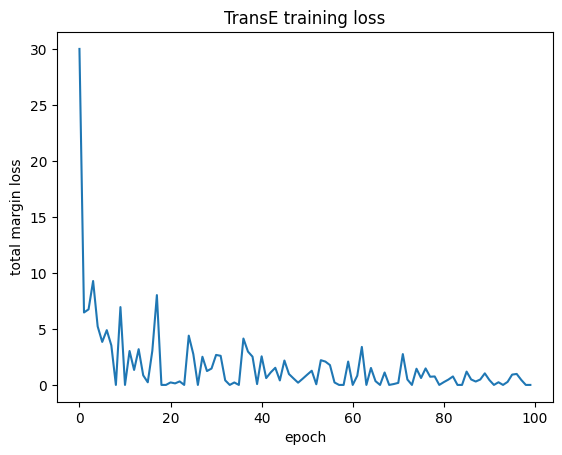

In [7]:
margin = 1.0
lr = 0.05
epochs = 100
loss_history = []

for epoch in range(epochs):
    np.random.shuffle(train_ids)
    total_loss = 0.0
    for h_id, r_id, t_id in train_ids:
        h_neg, t_neg = corrupt_triple(h_id, r_id, t_id, len(entities), train_id_set)

        pos_vec = E[h_id] + R[r_id] - E[t_id]
        neg_vec = E[h_neg] + R[r_id] - E[t_neg]
        pos_score = np.sum(pos_vec ** 2)
        neg_score = np.sum(neg_vec ** 2)
        loss = margin + pos_score - neg_score

        if loss > 0:
            total_loss += loss

            grad_pos = 2 * pos_vec
            grad_neg = 2 * neg_vec

            E[h_id]   -= lr * grad_pos
            E[t_id]   += lr * grad_pos
            E[h_neg]  += lr * grad_neg
            E[t_neg]  -= lr * grad_neg
            R[r_id]   -= lr * (grad_pos - grad_neg)

            # re-normalize touched entity embeddings
            for e_id in (h_id, t_id, h_neg, t_neg):
                E[e_id] /= np.linalg.norm(E[e_id])

    loss_history.append(total_loss)
    if epoch % 50 == 0:
        print(f"epoch {epoch:4d}  total margin loss = {total_loss:.4f}")

plt.plot(loss_history)
plt.xlabel("epoch"); plt.ylabel("total margin loss"); plt.title("TransE training loss")
plt.show()


# 6. Link prediction / KB completion evaluation

Now for a given triple $(h, r, t)$, we can treat $t$ as *missing* and rank **all** entities as tail candidates by their score $f_r(h, \cdot)$ (lower is better).

In [11]:
def rank_tail(h_id, r_id, t_id_true):
    '''Return the 1-indexed rank of the true tail among all entities scored as candidates.'''
    scores = np.array([score(h_id, r_id, cand) for cand in range(len(entities))])
    order = np.argsort(scores)
    rank = int(np.where(order == t_id_true)[0][0]) + 1
    return rank, order

ranks = []
print(f"{'head':<20}{'relation':<18}{'true tail':<16}{'rank':<6}{'top-1 prediction'}")
for h, r, t in test_triples:
    h_id, r_id, t_id = ent2id[h], rel2id[r], ent2id[t]
    rank, order = rank_tail(h_id, r_id, t_id)
    ranks.append(rank)
    print(f"{h:<20}{r:<18}{t:<16}{rank:<6}{id2ent[order[0]]}")

head                relation          true tail       rank  top-1 prediction
RobertDeNiro        actedIn           ABronxTale      2     Goodfellas
LeonardoDiCaprio    bornIn            LosAngeles      5     Titanic
TheDeparted         filmingLocation   Boston          5     LosAngeles
NewJersey           locatedIn         USA             1     USA
